### Check submission segmentations

Image shape (Height, Width, Channels): (1024, 1536, 3)
Unique values in Red (Arteries?): [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 22

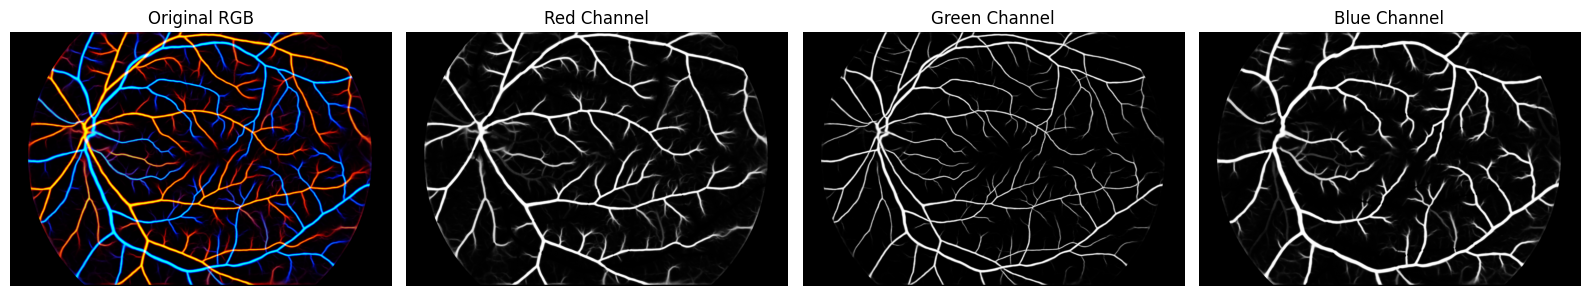

In [11]:
# Load png image and print the min and max value of each channel
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load a single segmentation mask
img_path = '/home/clara/R2-V2_materials/__predictions/baseline_av/av/g_051.png' 
# img_path = '/home/Data/GAVE2/external_data/Fundus-AVSeg/train/enhanced_masks/001_G.png'
# img_path = '/home/Data/GAVE2/training/masks/g_001.png'

img = Image.open(img_path)

# Convert to a numpy array for easy inspection
img_array = np.array(img)

# Verify the shape (e.g., 512, 512, 3 means it has 3 channels)
print(f"Image shape (Height, Width, Channels): {img_array.shape}")

# 2. Separate the channels
# In an RGB image array, index 0 is Red, 1 is Green, 2 is Blue
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# 3. Print unique pixel values per channel
# This tells you if your masks are truly binary (e.g., only containing 0 and 255) 
# or if there are anti-aliased/blended pixels in between.
print(f"Unique values in Red (Arteries?): {np.unique(R)}")
print(f"Unique values in Green (Veins?): {np.unique(G)}")
print(f"Unique values in Blue (All vessels?): {np.unique(B)}")

# 4. Visualize the channels
# We use cmap='gray' so the active pixels show up as white on a black background
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_array)
axes[0].set_title('Original RGB')

axes[1].imshow(R, cmap='gray')
axes[1].set_title('Red Channel')

axes[2].imshow(G, cmap='gray')
axes[2].set_title('Green Channel')

axes[3].imshow(B, cmap='gray')
axes[3].set_title('Blue Channel')

# Clean up axes for better viewing
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Check groundtruth segmentations

Image shape (Height, Width, Channels): (2336, 3504, 3)
Unique values in Red (Arteries?): [0]
Unique values in Green (Veins?): [  0 255]
Unique values in Blue (All vessels?): [0]


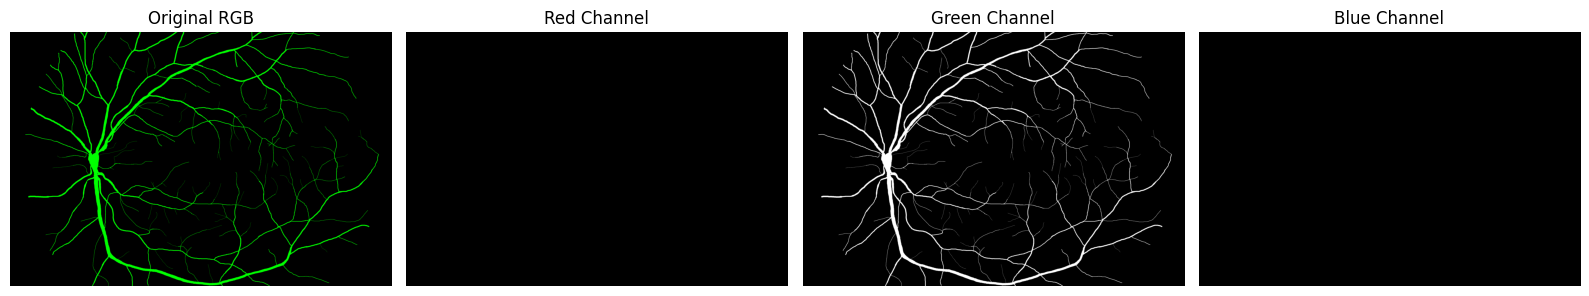

In [49]:
# Load png image and print the min and max value of each channel
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load a single segmentation mask
# img_path = '/home/clara/R2-V2_materials/__predictions/baseline_av/av/g_051.png' 
# img_path = '/home/Data/GAVE2/external_data/Fundus-AVSeg/train/av3/001_G.png'
# img_path = '/home/Data/GAVE2/training/av/g_001.png'
# img_path = '/home/Data/GAVE2/external_data/RITE/train/av3/21.png'
# img_path = '/home/Data/AFIO/AV-20191104T162310Z-001/AV/IM000001/IM000168--veins.jpg'
img_path = '/home/Data/unified_GAVE_datasets/HRF/label/01_dr.png'


img = Image.open(img_path)

# Convert to a numpy array for easy inspection
img_array = np.array(img)

# Verify the shape (e.g., 512, 512, 3 means it has 3 channels)
print(f"Image shape (Height, Width, Channels): {img_array.shape}")

# 2. Separate the channels
# In an RGB image array, index 0 is Red, 1 is Green, 2 is Blue
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# 3. Print unique pixel values per channel
# This tells you if your masks are truly binary (e.g., only containing 0 and 255) 
# or if there are anti-aliased/blended pixels in between.
print(f"Unique values in Red (Arteries?): {np.unique(R)}")
print(f"Unique values in Green (Veins?): {np.unique(G)}")
print(f"Unique values in Blue (All vessels?): {np.unique(B)}")

# 4. Visualize the channels
# We use cmap='gray' so the active pixels show up as white on a black background
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_array)
axes[0].set_title('Original RGB')

axes[1].imshow(R, cmap='gray')
axes[1].set_title('Red Channel')

axes[2].imshow(G, cmap='gray')
axes[2].set_title('Green Channel')

axes[3].imshow(B, cmap='gray')
axes[3].set_title('Blue Channel')

# Clean up axes for better viewing
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### For HRF and RITE that only have all vessels segmentation, leave only green channel

In [48]:
from pathlib import Path

import numpy as np
from PIL import Image

# Folder containing the label images
label_dir = Path("/home/Data/unified_GAVE_datasets/HRF/label")

# Process all PNG images
for img_path in label_dir.glob("*.png"):
    # Read image
    img = np.array(Image.open(img_path))

    # Check that the image has three channels
    if img.ndim != 3 or img.shape[2] != 3:
        print(f"Skipping {img_path.name}: not a 3-channel image.")
        continue

    # Keep only the second (green) channel
    img[:, :, 0] = 0  # Red channel
    img[:, :, 2] = 0  # Blue channel

    # Save back, overwriting the original file
    Image.fromarray(img).save(img_path)

    print(f"Processed {img_path.name}")

print("Done!")

Processed 15_dr.png
Processed 01_dr.png
Processed 06_dr.png
Processed 09_dr.png
Processed 11_dr.png
Processed 01_g.png
Processed 10_g.png
Processed 05_dr.png
Processed 02_g.png
Processed 14_dr.png
Processed 10_h.png
Processed 03_dr.png
Processed 09_h.png
Processed 14_h.png
Processed 08_h.png
Processed 14_g.png
Processed 02_dr.png
Processed 03_g.png
Processed 13_g.png
Processed 03_h.png
Processed 07_h.png
Processed 02_h.png
Processed 13_h.png
Processed 07_dr.png
Processed 15_g.png
Processed 07_g.png
Processed 04_g.png
Processed 12_dr.png
Processed 06_h.png
Processed 10_dr.png
Processed 04_dr.png
Processed 08_dr.png
Processed 05_h.png
Processed 08_g.png
Processed 11_h.png
Processed 05_g.png
Processed 12_h.png
Processed 13_dr.png
Processed 04_h.png
Processed 09_g.png
Processed 12_g.png
Processed 11_g.png
Processed 15_h.png
Processed 06_g.png
Processed 01_h.png
Done!


In [50]:
root_dir = '/home/Data/unified_GAVE_datasets/HRF/mask'

# Rename all files in the directory to replace '_mask' with ''
for img_path in Path(root_dir).glob("*.png"):
    new_name = img_path.name.replace('_mask', '')
    new_path = img_path.parent / new_name
    img_path.rename(new_path)
    print(f"Renamed {img_path.name} to {new_name}")

Renamed 13_dr_mask.png to 13_dr.png
Renamed 02_dr_mask.png to 02_dr.png
Renamed 13_g_mask.png to 13_g.png
Renamed 08_h_mask.png to 08_h.png
Renamed 09_dr_mask.png to 09_dr.png
Renamed 10_g_mask.png to 10_g.png
Renamed 09_g_mask.png to 09_g.png
Renamed 11_g_mask.png to 11_g.png
Renamed 15_h_mask.png to 15_h.png
Renamed 07_dr_mask.png to 07_dr.png
Renamed 15_dr_mask.png to 15_dr.png
Renamed 05_h_mask.png to 05_h.png
Renamed 06_dr_mask.png to 06_dr.png
Renamed 09_h_mask.png to 09_h.png
Renamed 15_g_mask.png to 15_g.png
Renamed 04_h_mask.png to 04_h.png
Renamed 11_dr_mask.png to 11_dr.png
Renamed 03_h_mask.png to 03_h.png
Renamed 14_g_mask.png to 14_g.png
Renamed 06_g_mask.png to 06_g.png
Renamed 03_dr_mask.png to 03_dr.png
Renamed 03_g_mask.png to 03_g.png
Renamed 12_dr_mask.png to 12_dr.png
Renamed 04_dr_mask.png to 04_dr.png
Renamed 01_g_mask.png to 01_g.png
Renamed 08_dr_mask.png to 08_dr.png
Renamed 05_g_mask.png to 05_g.png
Renamed 12_g_mask.png to 12_g.png
Renamed 10_dr_mask.png to 

Unique values in array: [  8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133
 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151
 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169
 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187
 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223
 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241
 242 243 244 245 246 247 24

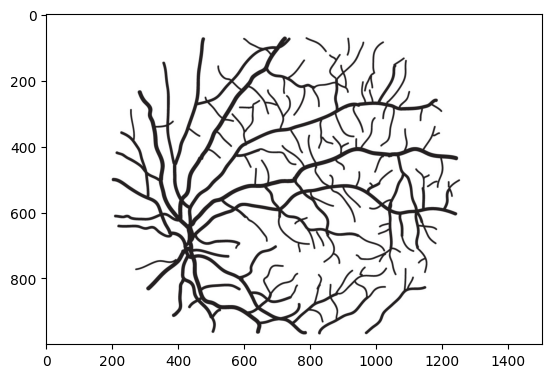

In [35]:
# Load png image and print the min and max value of each channel
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load a single segmentation mask
# img_path = '/home/clara/R2-V2_materials/__predictions/baseline_av/av/g_051.png' 
# img_path = '/home/Data/GAVE2/external_data/Fundus-AVSeg/train/av3/001_G.png'
# img_path = '/home/Data/GAVE2/training/av/g_001.png'
# img_path = '/home/Data/GAVE2/external_data/RITE/train/av3/21.png'
# img_path = '/home/Data/LES-AV/arteries-and-veins/111.png'
img_path = '/home/Data/AFIO/AV-20191104T162310Z-001/AV/IM000001/IM000001--vessels.jpg'

img = Image.open(img_path)

# Convert to a numpy array for easy inspection
img_array = np.array(img)

print(f"Unique values in array: {np.unique(img_array)}")


# Verify the shape (e.g., 512, 512, 3 means it has 3 channels)
print(f"Image shape (Height, Width, Channels): {img_array.shape}")

plt.imshow(img_array)

Original image shape (Height, Width, Channels): (1024, 1536, 3)


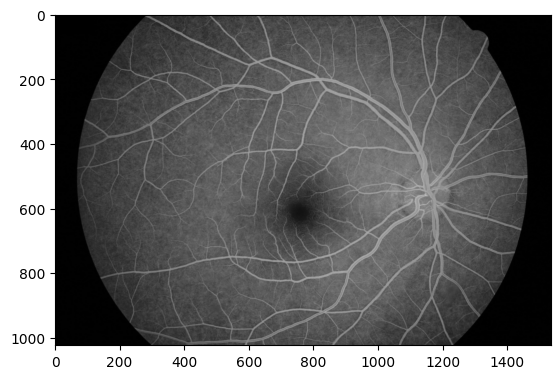

In [15]:
# Read original image and plot it in RGB
# original_img_path = '/home/Data/GAVE2/external_data/Fundus-AVSeg/train/enhanced/001_G.png'
original_img_path = '/home/Data/GAVE2/training/FFA_A/g_001.png'
original_img = Image.open(original_img_path)
print(f"Original image shape (Height, Width, Channels): {np.array(original_img).shape}")

plt.imshow(original_img)

### Binarize submission segmentations

In [8]:
import os
import numpy as np
from PIL import Image

input_dir = '/home/clara/R2-V2_materials/__predictions/baseline_av/av/'
output_dir = '/home/clara/R2-V2_materials/__predictions/baseline_av/optimized_av/'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    if filename.endswith(".png"):
        # 1. Load the image and ensure it is in RGB mode
        img = Image.open(os.path.join(input_dir, filename)).convert('RGB')
        
        # 2. Convert to a NumPy array for fast math operations
        img_array = np.array(img)
        
        # 3. Apply the Threshold (Binarization)
        # np.where works like this: (condition, value_if_true, value_if_false)
        # We also force the data type back to uint8 (standard image format)
        binarized_array = np.where(img_array > 127, 255, 0).astype(np.uint8)
        
        # 4. Convert the array back into a Pillow Image object
        img_binarized = Image.fromarray(binarized_array)
        
        # 5. Save the clean, binarized image with optimization
        img_binarized.save(os.path.join(output_dir, filename), optimize=True)

print("Binarization complete!")

Binarization complete!


### Quantize submission segmentations

In [9]:
import os
import numpy as np
from PIL import Image

input_dir = '/home/clara/R2-V2_materials/__predictions/baseline_av/av/'
output_dir = '/home/clara/R2-V2_materials/__predictions/baseline_av/optimized_av/'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# The 'step' size. 
# step=8 reduces 256 values to 32 levels. 
# If you want to be extremely conservative with your metrics, try step=4 (64 levels).
step = 4

for filename in os.listdir(input_dir):
    if filename.endswith(".png"):
        # Load the image
        img = Image.open(os.path.join(input_dir, filename)).convert('RGB')
        img_array = np.array(img, dtype=np.float32)
        
        # --- SOFT QUANTIZATION ONLY ---
        # Group similar probability values together without altering the spatial map
        quantized_array = np.round(img_array / step) * step
        
        # Ensure values stay strictly between 0 and 255, convert back to 8-bit
        quantized_array = np.clip(quantized_array, 0, 255).astype(np.uint8)
        
        # Save the optimized map
        img_quantized = Image.fromarray(quantized_array)
        
        # optimize=True removes header bloat
        # compress_level=9 forces the absolute maximum zlib compression for the PNG
        img_quantized.save(os.path.join(output_dir, filename), optimize=True, compress_level=9)

print("Quantization complete!")

Quantization complete!
